In [ ]:
# 한글 폰트를 설치합니다.

# !sudo apt-get install -y fonts-nanum
# !sudo fc-cache -fv
# !rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 45 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 18s (577 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 121913 files and direc

In [ ]:
# URL에 있는 파일을 다운로드 받습니다.

import urllib.request

urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/tykimos/tykimos.github.io/master/warehouse/dataset/tarr_train.txt",
    filename="tarr_train.txt",
)

('tarr_train.txt', <http.client.HTTPMessage at 0x7e8c4b047820>)

In [ ]:
# 정형데이터 분석 >> pandas

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# load file

train_file_path = "tarr_train.txt"

train_data = pd.read_csv(train_file_path, sep="\t")

train_data.head()

,id,comment,label
0,1,여기 음식은 언제 와도 실망시키지 않아요. 최고!,1
1,2,여기 라멘 진짜 ㄹㅇ 맛있어요. 국물이 진하고 면도 쫄깃해서 너무 좋았습니다.,1
2,3,"진짜 깔끔하고, 맛도 좋았어요. 추천합니다!",1
3,4,왜 이렇게 유명한지 모르겠음ㅋㅋ ㄹㅈㄷ 맛없음,0
4,5,인생 타르트를 여기서 만났어요❤️ 달지 않고 고소해서 정말 추천합니다!,1


In [ ]:
len(train_data)

300

In [ ]:
train_data['comment'].apply(len)

0      27
1      43
2      24
3      25
4      39
       ..
295    29
296    40
297    36
298    31
299    35
Name: comment, Length: 300, dtype: int64

In [ ]:
train_data['comment_length'] = train_data['comment'].apply(len)

In [ ]:
train_data['comment_length'][:3]

0    27
1    43
2    24
Name: comment_length, dtype: int64

In [ ]:
train_data['comment_length'].describe()

count    300.000000
mean      31.236667
std       10.682120
min        5.000000
25%       25.000000
50%       30.000000
75%       35.000000
max       92.000000
Name: comment_length, dtype: float64

In [ ]:
comment_length_statistics = train_data['comment_length'].describe()
comment_length_statistics

count    300.000000
mean      31.236667
std       10.682120
min        5.000000
25%       25.000000
50%       30.000000
75%       35.000000
max       92.000000
Name: comment_length, dtype: float64

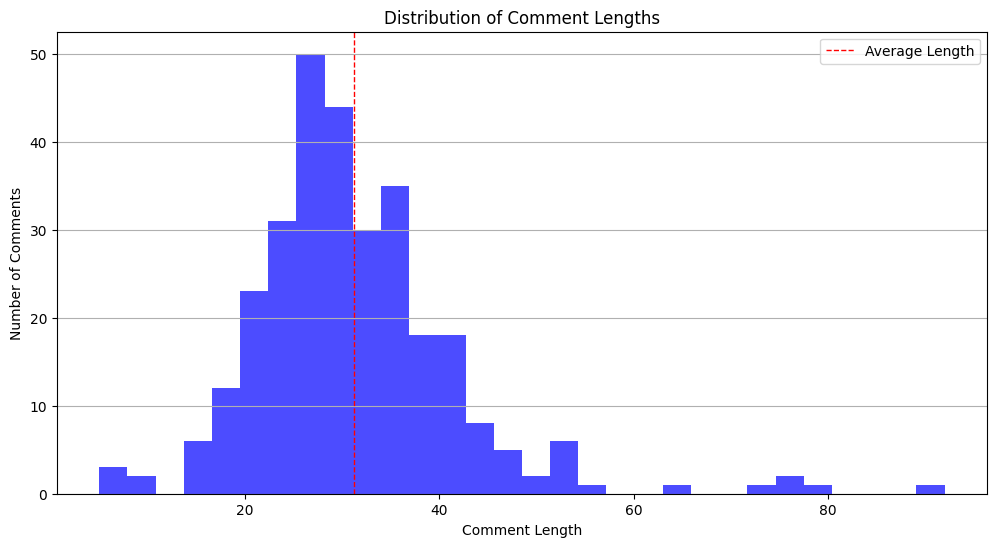

In [ ]:
# matplotlib : 데이터를 시각화하는데 많이 사용되는 패키지입니다.

import matplotlib.pyplot as plt

# Plotting the distribution of comment lengths
plt.figure(figsize=(12, 6))
plt.hist(train_data['comment_length'], bins=30, color='blue', alpha=0.7)
plt.axvline(train_data['comment_length'].mean(), color='red', linestyle='dashed', linewidth=1, label='Average Length')
plt.title('Distribution of Comment Lengths')
plt.xlabel('Comment Length')
plt.ylabel('Number of Comments')
plt.legend()
plt.grid(axis='y')
plt.show()

In [ ]:
train_data['label'].value_counts()

label
1    162
0    138
Name: count, dtype: int64

In [ ]:
label_count = train_data['label'].value_counts()
print(label_count)

label
1    162
0    138
Name: count, dtype: int64


In [ ]:
label_distribution = train_data['label'].value_counts(normalize=True)
print(label_distribution)

label
1    0.54
0    0.46
Name: proportion, dtype: float64


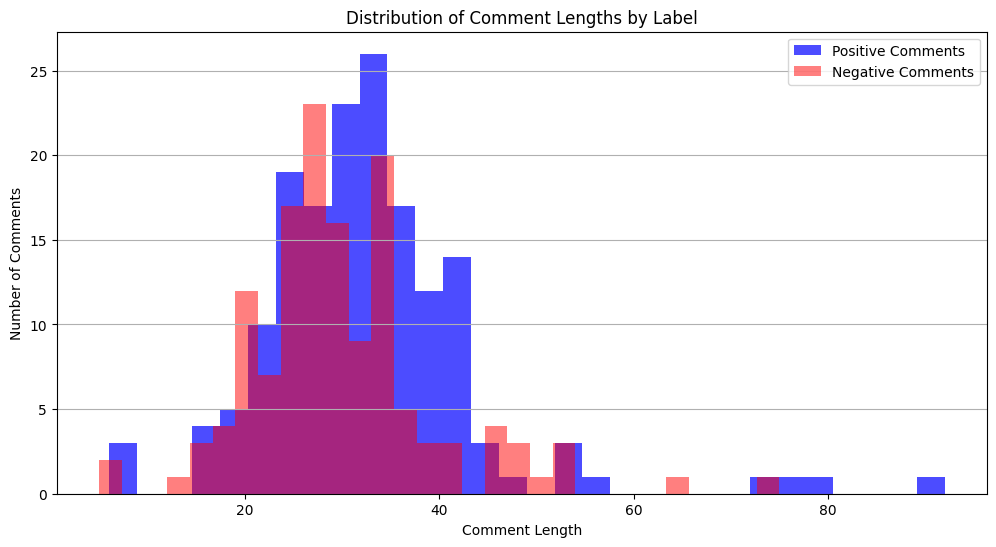

In [ ]:
# Plotting distribution of comment lengths by label
plt.figure(figsize=(12, 6))
plt.hist(train_data[train_data['label'] == 1]['comment_length'], bins=30, color='blue', alpha=0.7, label='Positive Comments')
plt.hist(train_data[train_data['label'] == 0]['comment_length'], bins=30, color='red', alpha=0.5, label='Negative Comments')
plt.title('Distribution of Comment Lengths by Label')
plt.xlabel('Comment Length')
plt.ylabel('Number of Comments')
plt.legend()
plt.grid(axis='y')
plt.show()

In [ ]:
from collections import Counter
import re

def get_word_fequencies(texts):
  words = []
  for text in texts:
    # 구두점을 제거한 후 공백 기준으로 토큰화
    words.extend(re.findall(r'\b\w+\b', text))

  # 단어 빈도수 계산
  return Counter(words)

In [ ]:
positive_comments = train_data[train_data['label']==1]['comment']
negative_comments = train_data[train_data['label']==0]['comment']

In [ ]:
print(positive_comments[:3])
print()
print(negative_comments[:3])

0                    여기 음식은 언제 와도 실망시키지 않아요. 최고!
1    여기 라멘 진짜 ㄹㅇ 맛있어요. 국물이 진하고 면도 쫄깃해서 너무 좋았습니다.
2                       진짜 깔끔하고, 맛도 좋았어요. 추천합니다!
Name: comment, dtype: object

3        왜 이렇게 유명한지 모르겠음ㅋㅋ ㄹㅈㄷ 맛없음
6           사진과 음식이 너무 달라서 실망했습니다.
8    솔직히...? 맛이 그닥이에요. 리뷰랑 너무 다르네.
Name: comment, dtype: object


In [ ]:
positive_word_freq = get_word_fequencies(positive_comments)
negative_word_freq = get_word_fequencies(negative_comments)

In [ ]:
print(positive_word_freq)
print()
print(negative_word_freq)

Counter({'여기': 31, '진짜': 23, '너무': 23, '좋아요': 16, '정말': 14, '이런': 14, '같아요': 11, '맛있어요': 9, '좋았어요': 8, '또': 8, '것': 8, '좋은': 8, '왔는데': 8, '메뉴': 7, '음식도': 7, '잘': 7, '우리': 7, '좀': 7, '음식은': 6, '최고': 6, '자주': 6, '이렇게': 6, '꼭': 6, '처음': 6, '분위기도': 6, '맛': 6, '딱': 6, '오랜만에': 6, '곳': 6, '와': 6, 'ㄹㅇ': 5, '좋았습니다': 5, '추천합니다': 5, 'ㅋㅋ': 5, '안': 5, '왜': 5, '이제야': 5, '여기는': 5, '친절해서': 5, '기분': 5, '좋게': 5, '있어서': 5, '거': 5, '모두': 5, '이': 5, '맛도': 4, '대박': 4, '곳이': 4, '다들': 4, '요기': 4, '좋고': 4, '분위기': 4, '맛있었어요': 4, '맛이': 4, '수': 4, '맛을': 4, '부드럽고': 4, '다시': 4, '음식이': 4, '음식': 4, '싶네요': 4, '언제': 3, '와도': 3, '가격도': 3, '다음에': 3, '앞으로': 3, '올': 3, '게': 3, 'ㅎㅎ': 3, '와서': 3, '먹었어요': 3, '메뉴도': 3, '맛있더라고요': 3, '오고': 3, '그냥': 3, '맛집을': 3, '맛있어서': 3, '좋아하시는': 3, '분들': 3, '와봤는데': 3, '훌륭했어요': 3, '괜찮았어요': 3, '직원들이': 3, '식사하는': 3, '서비스가': 3, '특히': 3, '친구': 3, '사진': 3, '그': 3, '있는': 3, '먹고': 3, '우와': 3, '데이트하기': 3, '다른': 3, '여긴': 3, '곳을': 3, '가격에': 3, '대박이에요': 3, '그래도': 3, '국물이': 2, '인생': 2, '않고': 2, '해주셔서': 2, 

In [ ]:
top_positive_words = positive_word_freq.most_common(10)
top_negative_words = negative_word_freq.most_common(10)

In [ ]:
print(top_positive_words)
print()
print(top_negative_words)

[('여기', 31), ('진짜', 23), ('너무', 23), ('좋아요', 16), ('정말', 14), ('이런', 14), ('같아요', 11), ('맛있어요', 9), ('좋았어요', 8), ('또', 8)]

[('너무', 42), ('좀', 23), ('안', 20), ('같아요', 14), ('음식이', 13), ('것', 13), ('올', 11), ('여기', 10), ('그냥', 10), ('왔는데', 9)]


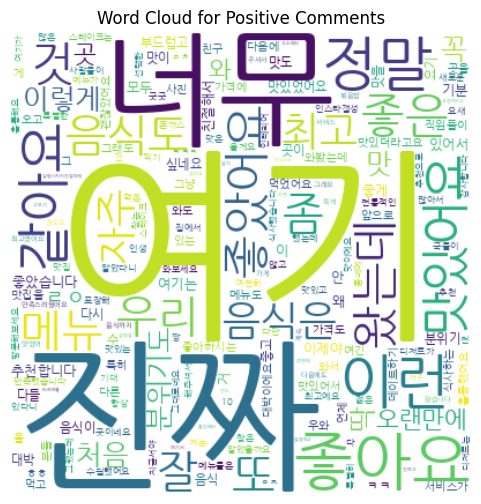

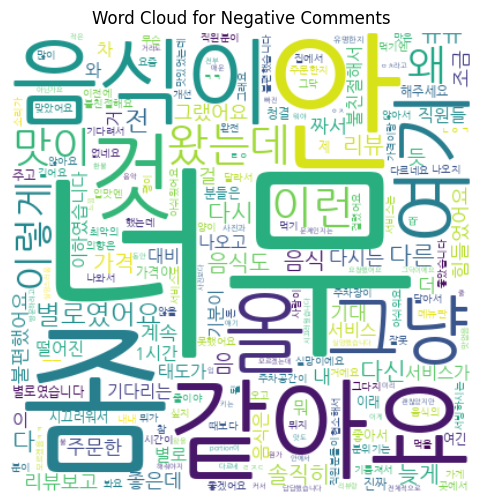

In [ ]:
from wordcloud import WordCloud

# Generate word clouds for positive and negative comments
def generate_wordcloud(word_freq, title):
    wc = WordCloud(width=400, height=400, background_color='white', font_path='NanumGothic.ttf').generate_from_frequencies(word_freq)
    plt.figure(figsize=(6, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(title)
    plt.axis('off')
    plt.show()

# Displaying word clouds
generate_wordcloud(positive_word_freq, 'Word Cloud for Positive Comments')
generate_wordcloud(negative_word_freq, 'Word Cloud for Negative Comments')

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# 텍스트 모음(corpus)에서 상위 n개의 n그램(ngram)을 반환하는 함수 생성

def get_top_ngrams(corpus, ngram_range, top_n):
  # 초기화
  vec = CountVectorizer(ngram_range=ngram_range).fit(corpus)
  bag_of_words = vec.transform(corpus)
  # 각 n그램의 총 빈도 계산
  # >> 결과물 : n그램 빈도를 나타내는 행렬
  sum_words = bag_of_words.sum(axis=0)
  # n-gram 과 그 빈도를 리스트로 변환
  words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
  words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True) #내림차순 정렬
  # key=lambda x: x[1] (word, freq) >> tuple 2번째 요소(빈도수) 기준
  return words_freq[:top_n]


# ngram_range
# n-그램의 범위를 지정하는 튜플.
# 예를 들어, (1, 2)는 유니그램과 바이그램을 모두 포함
# top_n: 반환할 상위 n개의 n-그램의 수

# vec = CountVectorizer(ngram_range=ngram_range).fit(corpus)
# fit(corpus) 메소드를 사용하여 주어진 corpus에 대해 피팅(fitting)을 수행
# >> 이 과정에서 각 n-그램에 대한 어휘 사전을 구축

In [ ]:
# top bigram, trigram

top_bigrams = get_top_ngrams(train_data['comment'], ngram_range=(2, 2), top_n=10)
# (2, 2) : bigram 추출 (두 단어로 구성된 n-gram)

top_trigrams = get_top_ngrams(train_data['comment'], ngram_range=(3, 3), top_n=10)
# (3, 3) : trigram 추출 (세 단어로 구성된 n-gram)

In [ ]:
top_bigrams

[('음식이 너무', 8),
 ('너무 친절해서', 5),
 ('친절해서 기분', 5),
 ('기분 좋게', 5),
 ('너무 짜서', 4),
 ('그냥 그랬어요', 4),
 ('분위기도 좋고', 4),
 ('서비스가 너무', 4),
 ('진짜 ㄹㅇ', 3),
 ('리뷰보고 왔는데', 3)]

In [ ]:
top_trigrams

[('너무 친절해서 기분', 5),
 ('친절해서 기분 좋게', 5),
 ('음식도 늦게 나오고', 3),
 ('분위기도 좋고 음식도', 3),
 ('직원들이 너무 친절해서', 3),
 ('진짜 ㄹㅇ 맛있어요', 2),
 ('음식이 너무 늦게', 2),
 ('이런 맛집을 지금서야', 2),
 ('왔을 때보다 서비스가', 2),
 ('많이 떨어진 같아요', 2)]

In [ ]:
get_top_ngrams(train_data[train_data['label']==1]['comment'], ngram_range=(2,2), top_n=10)

[('너무 친절해서', 5),
 ('친절해서 기분', 5),
 ('기분 좋게', 5),
 ('분위기도 좋고', 4),
 ('진짜 ㄹㅇ', 3),
 ('이런 맛집을', 3),
 ('좋아하시는 분들', 3),
 ('처음 와봤는데', 3),
 ('좋고 음식도', 3),
 ('직원들이 너무', 3)]

In [ ]:
top_bigrams_positive = get_top_ngrams(train_data[train_data['label']==1]['comment'], ngram_range=(2,2), top_n=10)
top_trigrams_positive = get_top_ngrams(train_data[train_data['label']==1]['comment'], ngram_range=(3,3), top_n=10)

top_bigrams_negative = get_top_ngrams(train_data[train_data['label']==0]['comment'], ngram_range=(2,2), top_n=10)
top_trigrams_negative = get_top_ngrams(train_data[train_data['label']==0]['comment'], ngram_range=(3,3), top_n=10)

In [ ]:
top_bigrams_positive, top_trigrams_positive

([('너무 친절해서', 5),
  ('친절해서 기분', 5),
  ('기분 좋게', 5),
  ('분위기도 좋고', 4),
  ('진짜 ㄹㅇ', 3),
  ('이런 맛집을', 3),
  ('좋아하시는 분들', 3),
  ('처음 와봤는데', 3),
  ('좋고 음식도', 3),
  ('직원들이 너무', 3)],
 [('너무 친절해서 기분', 5),
  ('친절해서 기분 좋게', 5),
  ('분위기도 좋고 음식도', 3),
  ('직원들이 너무 친절해서', 3),
  ('진짜 ㄹㅇ 맛있어요', 2),
  ('이런 맛집을 지금서야', 2),
  ('좋아하시는 분들 와보세요', 2),
  ('여기 인테리어 너무', 2),
  ('친구 추천으로 왔는데', 2),
  ('사진 찍기 좋아요', 2)])

In [ ]:
top_bigrams_negative, top_trigrams_negative

([('음식이 너무', 7),
  ('너무 짜서', 4),
  ('그냥 그랬어요', 4),
  ('리뷰보고 왔는데', 3),
  ('기대 이하였습니다', 3),
  ('음식도 늦게', 3),
  ('늦게 나오고', 3),
  ('떨어진 같아요', 3),
  ('가격 대비', 3),
  ('너무 시끄러워서', 3)],
 [('음식도 늦게 나오고', 3),
  ('음식이 너무 늦게', 2),
  ('많이 떨어진 같아요', 2),
  ('음식이 너무 짜서', 2),
  ('너무 짜서 먹기', 2),
  ('짜서 먹기 힘들었어요', 2),
  ('오고 싶지 않아요', 2),
  ('리뷰 좋아서 왔는데', 2),
  ('여긴 이렇게 사람이', 2),
  ('여기 리뷰 이래', 2)])

In [ ]:
keywords = ['서비스','가격','맛','분위기','직원']

keyword_counts = {keyword: train_data['comment'].str.count(keyword).sum() for keyword in keywords}
# keyword_counts 는 keyword 가 key 값으로 활용. 해당 키워드의 빈도수를 value 로 갖는 dict()

keyword_counts

{'서비스': 19, '가격': 19, '맛': 85, '분위기': 15, '직원': 20}

In [ ]:
positive_keyword_counts = {keyword: train_data[train_data['label']==1]['comment'].str.count(keyword).sum() for keyword in keywords}
# keyword_counts 는 keyword 가 key 값으로 활용. 해당 키워드의 빈도수를 ㄱ밧으로 갖는 dict()
negative_keyword_counts = {keyword: train_data[train_data['label']==0]['comment'].str.count(keyword).sum() for keyword in keywords}
# keyword_counts 는 keyword 가 key 값으로 활용. 해당 키워드의 빈도수를 ㄱ밧으로 갖는 dict()

positive_keyword_counts, negative_keyword_counts

({'서비스': 8, '가격': 8, '맛': 63, '분위기': 13, '직원': 11},
 {'서비스': 11, '가격': 11, '맛': 22, '분위기': 2, '직원': 9})

<ipython-input-44-28a747f56008>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(positive_keyword_counts.keys()), y=list(positive_keyword_counts.values()), ax=ax[0], palette='Blues_d')
<ipython-input-44-28a747f56008>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(negative_keyword_counts.keys()), y=list(negative_keyword_counts.values()), ax=ax[1], palette='Reds_d')
<ipython-input-44-28a747f56008>:20: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from current font.
  plt.tight_layout()
<ipython-input-44-28a747f56008>:20: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from current font.
  plt.tight_layout()
<ipython-input-44-28a747f56008>:20: UserWarn

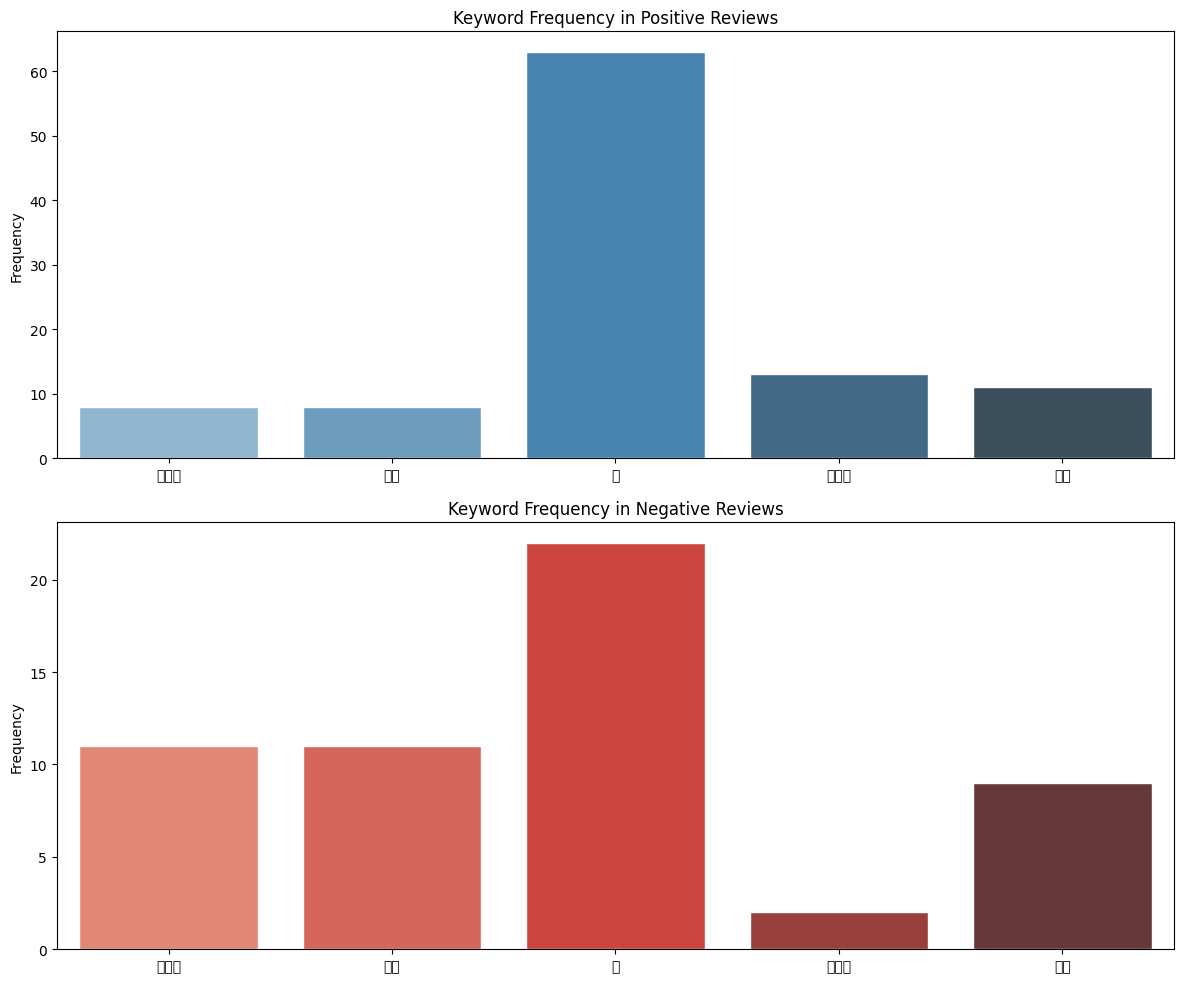

In [ ]:
import seaborn as sns

# Visualizing keyword frequency for positive and negative labels

# Plotting
fig, ax = plt.subplots(2, 1, figsize=(12, 10))

sns.set(font="NanumGothic", rc={"axes.unicode_minus":False}, style='white')

# Positive reviews
sns.barplot(x=list(positive_keyword_counts.keys()), y=list(positive_keyword_counts.values()), ax=ax[0], palette='Blues_d')
ax[0].set_title("Keyword Frequency in Positive Reviews")
ax[0].set_ylabel("Frequency")

# Negative reviews
sns.barplot(x=list(negative_keyword_counts.keys()), y=list(negative_keyword_counts.values()), ax=ax[1], palette='Reds_d')
ax[1].set_title("Keyword Frequency in Negative Reviews")
ax[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

In [ ]:
# 텍스트 코퍼스에서 TF-IDF 점수가 가장 높은 상위 top_n 개의 단어를 반환 함수 생성

def get_top_tfidf_features(corpus, top_n):
  # tfidf 행렬 생성
  tfidf_vec = TfidfVectorizer().fit(corpus)
  transformed = tfidf_vec.transform(corpus)
  mean_tfidf = transformed.mean(axis=0).tolist()[0]
  # transformed 행렬의 각 열의 평균 tfidf 값을 계산 >> list 로 변환
  sorted_tfidf_index = np.argsort(mean_tfidf)[-top_n:] #  상위 top_n

  sorted_tfidf_values = [mean_tfidf[i] for i in sorted_tfidf_index]
  # 상위 top_n의 단어에 해당하는 평균 tfidf 값을 리스트로 담기

  sorted_tfidf_features = [tfidf_vec.get_feature_names_out()[i] for i in sorted_tfidf_index]
  # 상위 top_n개의 단어 자체를 담은 리스트

  return list(zip(sorted_tfidf_features, sorted_tfidf_values))
  # 상위 top_n개의 단어와 그에 대응하는 tfidf 값 >> 튜플 형태 결합 >> 리스트 변환


top_tfidf_features = get_top_tfidf_features(train_data['comment'], top_n=10)
top_tfidf_features


[('그냥', 0.013687376648590821),
 ('정말', 0.014749058066344661),
 ('좋아요', 0.014972658609432315),
 ('음식이', 0.01691058446184101),
 ('왔는데', 0.017129225820536793),
 ('이런', 0.019819055177452125),
 ('같아요', 0.020639435969586072),
 ('진짜', 0.024167310616650294),
 ('여기', 0.031209780984430703),
 ('너무', 0.04233601334982538)]

In [ ]:
top_tfidf_positive = get_top_tfidf_features(train_data[train_data['label']==1]['comment'], top_n=10)
top_tfidf_negative = get_top_tfidf_features(train_data[train_data['label']==0]['comment'], top_n=10)

In [ ]:
top_tfidf_positive

[('좋은', 0.015794573515558488),
 ('왔는데', 0.016700611449025134),
 ('같아요', 0.01877905877210045),
 ('맛있어요', 0.020917787452746334),
 ('이런', 0.022451006535394235),
 ('정말', 0.025829318842390096),
 ('좋아요', 0.025855855648262004),
 ('너무', 0.034610136670802),
 ('진짜', 0.037387900220376004),
 ('여기', 0.04163214429506404)]

In [ ]:
top_tfidf_negative

[('이렇게', 0.015448051934657724),
 ('별로였어요', 0.017845587667163616),
 ('맛이', 0.02009740100089326),
 ('이런', 0.020486778220176298),
 ('왔는데', 0.020911414159821392),
 ('그냥', 0.02315386264694077),
 ('여기', 0.023508509590134744),
 ('같아요', 0.026674037078069108),
 ('음식이', 0.028554791673134402),
 ('너무', 0.05873634746611193)]

In [ ]:
corpus = [
    "I love machine learning and artificial intelligence",
    "Machine learning is fascinating",
    "I love learning new things about Gen-AI and ML"
]

In [ ]:
get_top_tfidf_features(corpus, 5)

[('is', 0.194827633673355),
 ('and', 0.21797712997197954),
 ('love', 0.21797712997197954),
 ('machine', 0.2736150192293466),
 ('learning', 0.2843470255464275)]

추가학습
- 그래서 준비했습니다.

In [ ]:
# argsort()

import numpy as np

# 예시 배열
arr = np.array([10, 3, 5, 2])
# [2,3,5,10]
# 배열을 정렬했을 때의 인덱스 반환
sorted_indices = np.argsort(arr)
print(sorted_indices)

# 배열의 가장 작은 값인 2 >> 원래 index 가 3에 있었음
# 가장 큰 값 10 >> 원래 index 0

[3 1 2 0]


In [ ]:
top_2_indices = sorted_indices[-2:]
print(top_2_indices)

[2 0]
